In [1]:
# --- data_prep.py ---
import pandas as pd
from sklearn.preprocessing import StandardScaler

def load_numeric_frame(csv_path):
    df = pd.read_csv(csv_path)
    X = df.select_dtypes(include=["number"]).dropna(axis=1, how="all")
    X = X.dropna(axis=0)            # simple drop; try imputation later
    cols = X.columns
    X_scaled = StandardScaler().fit_transform(X)
    return X, X_scaled, cols


In [2]:
df = pd.read_csv(r'./data/merge_dominance.csv', low_memory=False)
for col in df.columns:
  print(col)

X, X_scaled, cols = load_numeric_frame(r'./data/merge_dominance.csv')


season
week
game_id
home_game_date
home_team
away_team
home_points_for
away_points_for
point_diff
winner
home_prior_pf_avg_3
home_prior_pa_avg_3
home_prior_win_pct_3
home_prior_pf_avg_5
home_prior_pa_avg_5
home_prior_win_pct_5
away_prior_pf_avg_3
away_prior_pa_avg_3
away_prior_win_pct_3
away_prior_pf_avg_5
away_prior_pa_avg_5
away_prior_win_pct_5
home_minus_away_pf_avg_3
home_minus_away_pa_avg_3
home_minus_away_win_pct_3
home_minus_away_pf_avg_5
home_minus_away_pa_avg_5
home_minus_away_win_pct_5
home_moneyline_prob
away_moneyline_prob
moneyline_prob_diff
spread_line
total_line
home_rest
away_rest
rest_diff
home_win
trend_home_minus_away_pf_avg_3_w3
trend_home_minus_away_pa_avg_3_w3
trend_home_minus_away_win_pct_3_w3
trend_home_minus_away_pf_avg_5_w3
trend_home_minus_away_pa_avg_5_w3
trend_home_minus_away_win_pct_5_w3
trend_home_minus_away_pf_avg_3_w5
trend_home_minus_away_pa_avg_3_w5
trend_home_minus_away_win_pct_3_w5
trend_home_minus_away_pf_avg_5_w5
trend_home_minus_away_pa_avg_5_w5


In [3]:
# --- cluster_fit.py ---
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def cluster_and_reduce(X_scaled, k=4):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(X_scaled)
    centers2 = pca.transform(km.cluster_centers_)
    return labels, X2, centers2, km, pca


In [4]:
# --- elbow_silhouette.py ---
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

def find_k(X_scaled, k_range=range(2, 11)):
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = km.inertia_  # elbow metric
        results.append((k, sil, inertia))
    return results


In [5]:
# --- plots_matplotlib.py ---
import matplotlib.pyplot as plt

def plot_clusters_matplotlib(X2, labels, centers2):
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(X2[:,0], X2[:,1], c=labels, cmap="tab10", s=18, alpha=0.9)
    plt.scatter(centers2[:,0], centers2[:,1], c="black", s=120, marker="X", edgecolor="white")
    plt.title("K-Means clusters (PCA 2D) • Matplotlib")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=.2)
    plt.show()


In [6]:
# --- plots_seaborn.py ---
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_clusters_seaborn(X2, labels):
    sns.set_theme()  # nice styling
    plot_df = pd.DataFrame(dict(PC1=X2[:,0], PC2=X2[:,1], cluster=labels))
    ax = sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", s=30)
    ax.set_title("K-Means clusters (PCA 2D) • Seaborn")
    plt.show()

def quick_corr_heatmap(df_num):
    plt.figure(figsize=(8,6))
    sns.heatmap(df_num.corr(), vmin=-1, vmax=1, center=0, annot=False, cmap="vlag")
    plt.title("Feature correlation heatmap")
    plt.show()

def pairplot_small(df_num, cols=6):
    sns.pairplot(df_num.iloc[:, :cols], corner=True, diag_kind="hist")
    plt.show()


k= 2 | silhouette=0.207 | inertia=57495
k= 3 | silhouette=0.125 | inertia=52932
k= 4 | silhouette=0.116 | inertia=50126
k= 5 | silhouette=0.100 | inertia=47946
k= 6 | silhouette=0.098 | inertia=46587
k= 7 | silhouette=0.089 | inertia=45371
k= 8 | silhouette=0.078 | inertia=44333
k= 9 | silhouette=0.078 | inertia=43698
k=10 | silhouette=0.072 | inertia=42789


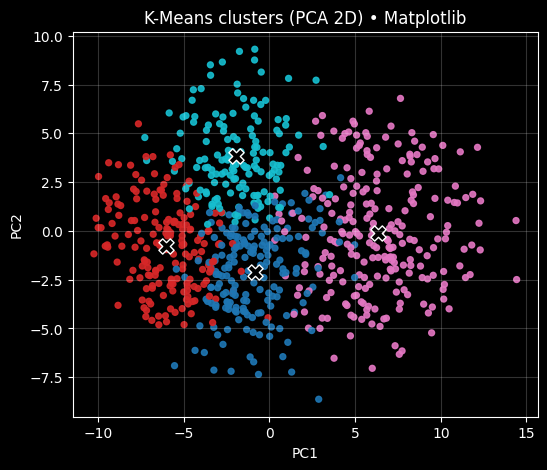

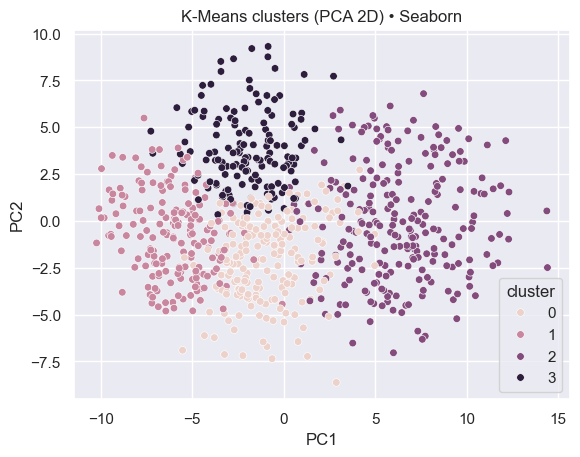

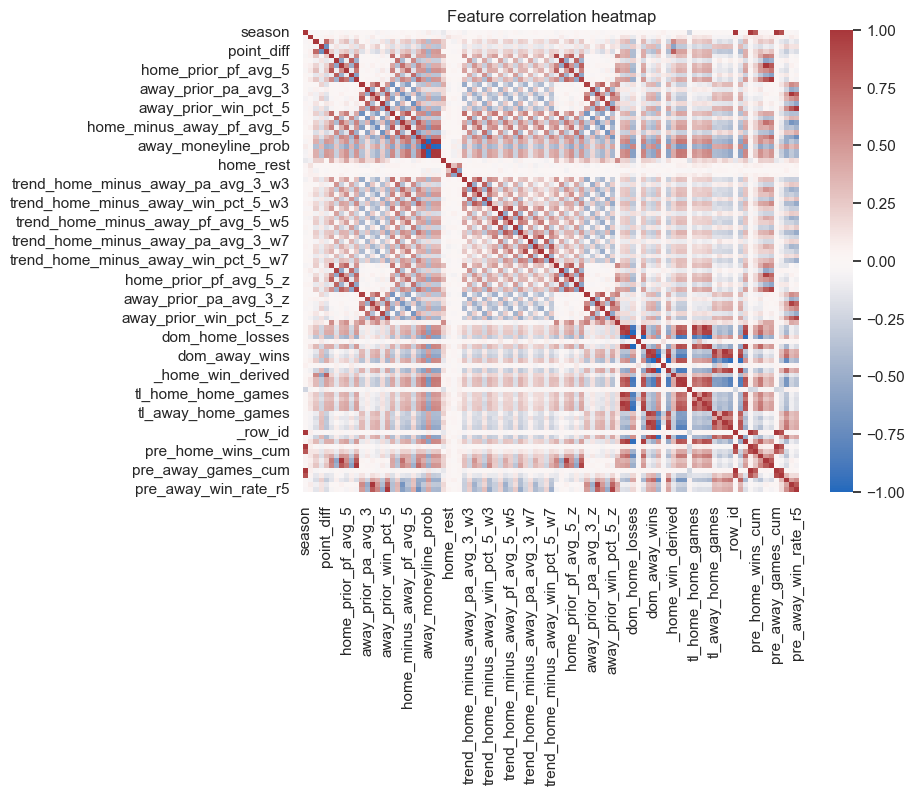

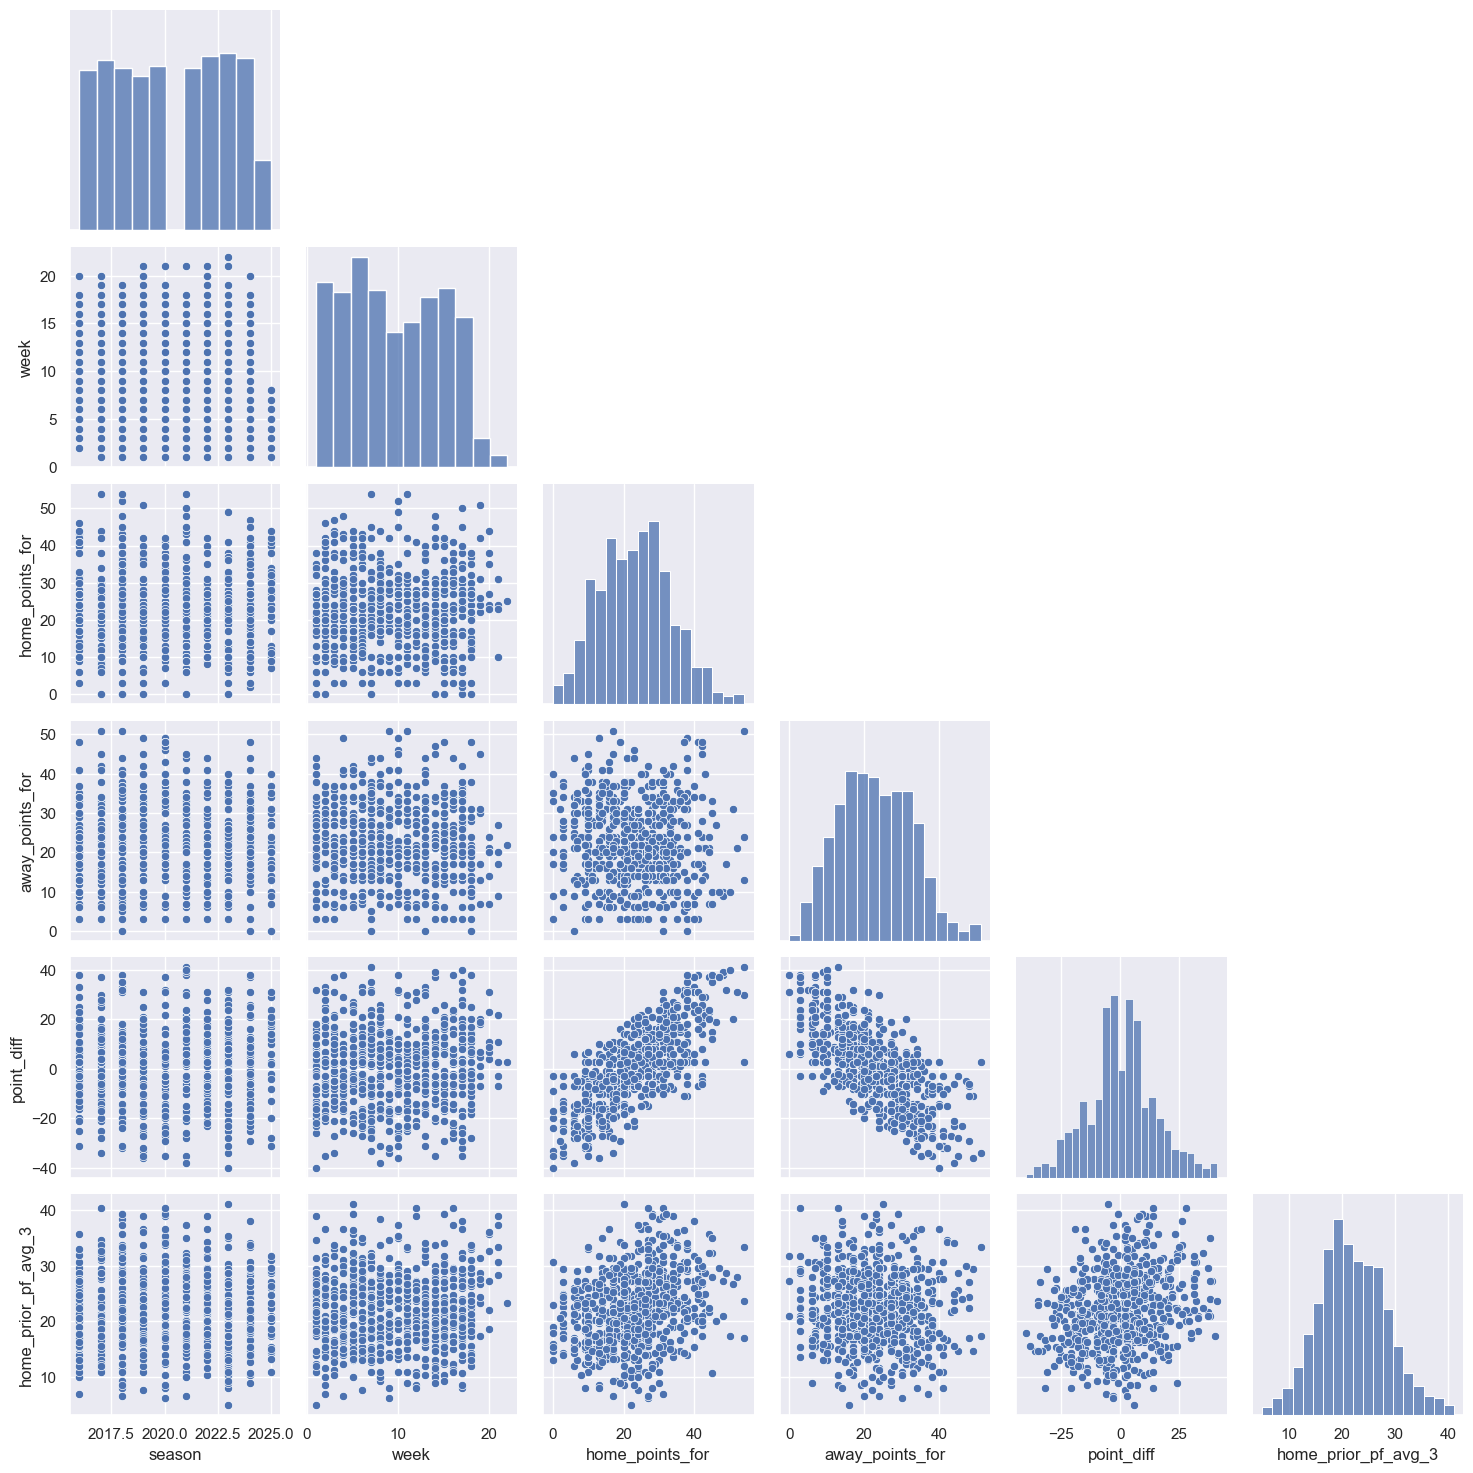

In [10]:


# 1) Load (try 'weekly_train.csv' or any tabular CSV you have)
X, X_scaled, cols = load_numeric_frame("./data/merge_dominance.csv")

# 2) Pick k smartly
for k, sil, inertia in find_k(X_scaled):
    print(f"k={k:2d} | silhouette={sil:.3f} | inertia={inertia:.0f}")

# 3) Fit with your chosen k (say k=4)
labels, X2, centers2, km, pca = cluster_and_reduce(X_scaled, k=4)

# 4) Visualize
plot_clusters_matplotlib(X2, labels, centers2)   # precise control
plot_clusters_seaborn(X2, labels)                # quick, pretty
quick_corr_heatmap(X)                            # understand features
pairplot_small(X)                                # small subset pairwise


In [16]:
# Utility: nicely display DataFrames in this notebook
# Purpose: Provide a single helper to render DataFrames with a heading and
# safe handling so subsequent cells can call display_dataframe_to_user(...)
# without raising NameError. Small, focused and non-intrusive.
from IPython.display import display, HTML
import pandas as pd

def display_dataframe_to_user(name: str, dataframe):
    """Display a DataFrame (or other object) with a concise HTML heading.

    Args:
        name: Short title shown above the table.
        dataframe: A pandas DataFrame or any displayable object.
    """
    # Heading for quick visual separation in notebook output
    try:
        display(HTML(f"<h4 style='margin:6px 0 4px 0;font-family:Arial'>{name}</h4>"))
    except Exception:
        # If HTML display fails (non-notebook env), fall back to print
        print(name)

    # If it's a DataFrame, display it directly; otherwise show the object
    if isinstance(dataframe, pd.DataFrame):
        # Limit display width/rows handled by user's environment; keep this call simple
        display(dataframe)
    else:
        display(dataframe)


Missingness (numeric columns)                              column  missing  pct_missing
0           _dom_delta_emp_home_win     1932        70.31
1                 pre_away_wins_cum      162         5.90
2             pre_away_win_rate_cum      162         5.90
3                 _home_win_derived      160         5.82
4             pre_home_win_rate_cum      158         5.75
..                              ...      ...          ...
89  tl_home_away_win_rate_when_away        0         0.00
90       tl_away_total_games_listed        0         0.00
91               tl_away_away_games        0         0.00
92  tl_away_home_win_rate_when_home        0         0.00
93                          _row_id        0         0.00

[94 rows x 3 columns]


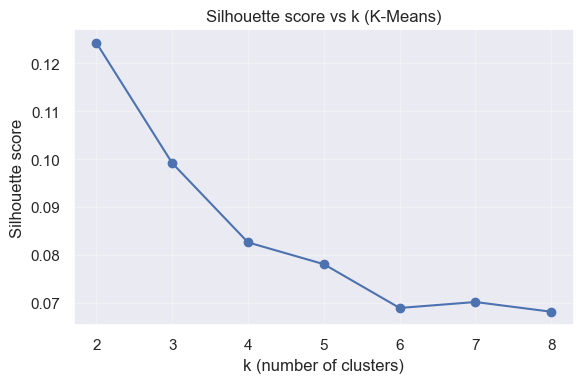

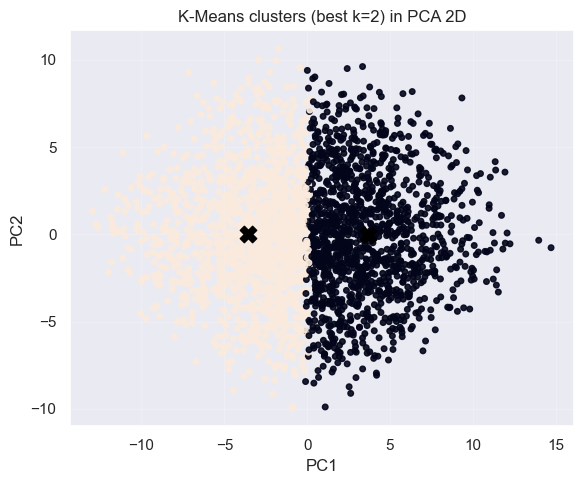

,cluster,moneyline_prob_diff,home_moneyline_prob,away_moneyline_prob,spread_line,total_line,rest_diff,dom_home_win_pct,dom_away_win_pct,season_home_win_rate,pre_home_win_rate_cum,pre_away_win_rate_cum,pre_home_win_rate_r3,pre_away_win_rate_r3,pre_home_win_rate_r5,pre_away_win_rate_r5,home_win_rate (external),n_games
0,0,0.362,0.697,0.334,5.730,45.273,0.119,0.541,0.454,0.554,0.552,0.453,0.624,0.385,0.624,0.382,0.705,1352
1,1,-0.117,0.457,0.574,-1.805,45.378,-0.062,0.458,0.538,0.553,0.451,0.547,0.352,0.638,0.376,0.616,0.405,1396


,rows,columns_total,numeric_used,k_best,silhouette_best
0,2748,168,93,2,0.124


In [17]:
# W1 — Unsupervised ML on Christopher's merge_dominance.csv (Matplotlib-only plotting)
# ----------------------------------------------------------------------------
# This single cell walks through a compact, *teachable* workflow:
# 1) Load and inspect the dataset (numeric selection, basic quality checks).
# 2) Preprocess for unsupervised learning (drop clear leakage, handle missing, scale).
# 3) Dimensionality reduction (PCA→2D) for visualization.
# 4) Clustering with K-Means (k=2..8), silhouette selection, final fit.
# 5) Visualizations: silhouette curve and 2D cluster scatter with centroids.
# 6) Cluster “profiling”: helpful per-cluster means for football-relevant features.
#
# Notes:
# • Plots use *matplotlib only* per tool constraints (no seaborn).
# • We keep everything pre-game as much as possible (avoid obvious leakage columns).
# • We include an optional "external" check against `home_win` only for interpretation;
#   the clustering itself never uses the label.
#
# You can re-run this cell safely; it produces the same figures/tables each time.
#
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# -----------------------------
# 0) Load the dataset
# -----------------------------
CSV_PATH = "./data/merge_dominance.csv"  # provided location

df_raw = pd.read_csv(CSV_PATH)

# -----------------------------
# 1) Basic inspection (quick)
# -----------------------------
n_rows, n_cols = df_raw.shape

# Select numeric columns only for unsupervised learning (models expect numbers)
numeric_df = df_raw.select_dtypes(include=["number"]).copy()

# We will *avoid obvious post-game leakage* columns so clusters reflect pre-game structure.
# These columns encode the actual outcome and would trivialize clustering:
leakage_cols = {
    "home_points_for", "away_points_for", "point_diff"
}
# Keep only numeric columns **minus** leakage ones that happen to exist.
numeric_df = numeric_df.drop(columns=[c for c in leakage_cols if c in numeric_df.columns], errors="ignore")

# Quick missingness snapshot (count of NaNs per numeric column)
missing_counts = numeric_df.isna().sum().sort_values(ascending=False)
missing_overview = pd.DataFrame({
    "missing": missing_counts,
    "pct_missing": (missing_counts / len(numeric_df) * 100).round(2)
})
print("Missingness (numeric columns)", missing_overview.reset_index().rename(columns={"index":"column"}))

# -----------------------------
# 2) Preprocess for unsupervised
# -----------------------------
# (a) Drop columns that are mostly missing (e.g., > 40% NaN) — configurable threshold
mostly_nan_cols = missing_overview[missing_overview["pct_missing"] > 40.0].index.tolist()
X = numeric_df.drop(columns=mostly_nan_cols, errors="ignore")

# (b) Median-impute remaining missing values (simple, robust default)
X = X.fillna(X.median(numeric_only=True))

# (c) Scale features — K-Means + PCA both benefit from standardized inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3) Dimensionality reduction
# -----------------------------
# Reduce to 2D only for plotting and intuitive understanding.
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# -----------------------------
# 4) K-Means selection via silhouette
# -----------------------------
k_candidates = list(range(2, 9))  # try 2..8 clusters
silhouette_scores = []

for k in k_candidates:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = kmeans.fit_predict(X_scaled)  # cluster on full feature space
    sil = silhouette_score(X_scaled, labels_k)  # silhouette in original (scaled) space
    silhouette_scores.append(sil)

# Pick the k with the best (max) silhouette score
best_k_idx = int(np.argmax(silhouette_scores))
best_k = k_candidates[best_k_idx]

# Fit final model at best_k and get labels/centers
kmeans_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels = kmeans_best.fit_predict(X_scaled)
centers_2d = pca.transform(kmeans_best.cluster_centers_)  # center locations in PCA space for plotting

# -----------------------------
# 5) Visualizations (matplotlib-only)
# -----------------------------

# (a) Silhouette vs k
plt.figure(figsize=(6,4))
plt.plot(k_candidates, silhouette_scores, marker="o")
plt.title("Silhouette score vs k (K-Means)")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (b) PCA 2D scatter colored by cluster
# Simple, readable palette: cycle default colors
plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=16, alpha=0.9)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="black", s=140, marker="X")
plt.title(f"K-Means clusters (best k={best_k}) in PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Cluster profiling (football-flavored)
# -----------------------------
# We compute per-cluster means for a curated set of columns that are:
# • interpretable (odds, spreads, rest) and
# • likely pre-game (should exist before kickoff).
candidate_profile_cols = [
    "moneyline_prob_diff", "home_moneyline_prob", "away_moneyline_prob",
    "spread_line", "total_line", "rest_diff",
    "dom_home_win_pct", "dom_away_win_pct", "season_home_win_rate",
    "pre_home_win_rate_cum", "pre_away_win_rate_cum",
    "pre_home_win_rate_r3", "pre_away_win_rate_r3",
    "pre_home_win_rate_r5", "pre_away_win_rate_r5",
]

# Keep only those present in X
profile_cols = [c for c in candidate_profile_cols if c in X.columns]

profile_df = pd.DataFrame({"cluster": labels})
for c in profile_cols:
    profile_df[c] = X[c].values  # X is imputed, so safe

cluster_profile = profile_df.groupby("cluster")[profile_cols].mean().round(3)

# Optional external check: if 'home_win' label exists (for interpretation only)
if "home_win" in df_raw.columns:
    # Align to same rows used in X (we dropped some mostly-missing cols, but not rows)
    # We need to account for any original NaNs before imputation that could cause index drift.
    # Since we used median fill without row drops (other than leakage cols), index alignment is OK.
    label_series = df_raw.loc[X.index, "home_win"]

    # Coerce a variety of plausible encodings to numeric 0/1 so mean() works robustly.
    def coerce_home_win(s: pd.Series) -> pd.Series:
        """Return a float Series with values 1.0 for wins, 0.0 for losses, NaN for unknown.

        Handles booleans, numeric 0/1, and common string encodings like 'W'/'L', 'win'/'loss',
        'True'/'False', 'yes'/'no'. Falls back to numeric coercion where possible.
        """
        # If already numeric or boolean, coerce directly
        if pd.api.types.is_bool_dtype(s) or pd.api.types.is_numeric_dtype(s):
            return pd.to_numeric(s, errors='coerce').astype(float)
        s_str = s.astype(str).str.strip().str.lower()
        mapping = {
            'true': 1, 'false': 0, '1': 1, '0': 0,
            'w': 1, 'l': 0, 'win': 1, 'loss': 0,
            'yes': 1, 'no': 0, 't': 1, 'f': 0,
            'y': 1, 'n': 0
        }
        mapped = s_str.map(mapping)
        # fallback: try numeric conversion on original series
        numeric_fallback = pd.to_numeric(s, errors='coerce')
        result = mapped.fillna(numeric_fallback).astype(float)
        return result

    label_series_num = coerce_home_win(label_series)

    ext_check = pd.DataFrame({"cluster": labels, "home_win": label_series_num})
    # drop rows where home_win could not be interpreted
    ext_check = ext_check.dropna(subset=["home_win"]) 
    cluster_hw_rate = ext_check.groupby("cluster")["home_win"].mean().round(3)
    # Ensure cluster_profile receives the aligned values (index is cluster)
    cluster_profile["home_win_rate (external)"] = cluster_hw_rate

# Add counts per cluster for context
counts = pd.Series(labels).value_counts().sort_index()
cluster_profile["n_games"] = counts

# Nicely display the cluster profile
display_dataframe_to_user(
    name=f"Cluster profile (best k={best_k}) — per-cluster means",
    dataframe=cluster_profile.reset_index().rename(columns={"index":"cluster"})
)

# Also show a tiny “header” summary table for quick reference
summary_df = pd.DataFrame({
    "rows": [n_rows],
    "columns_total": [n_cols],
    "numeric_used": [X.shape[1]],
    "k_best": [best_k],
    "silhouette_best": [round(silhouette_scores[best_k_idx], 3)],
})
display_dataframe_to_user("Run summary", summary_df)
